# ThemeDrift: Detecting Investment Themes from 10-K Filings

**COS 484 — NLP Final Project**  
Princeton University · April 2026

---

### Abstract

We ask whether language in annual 10-K filings can identify investment themes **before** thematic ETFs formally capture them. Using three snapshot years (2019, 2021, 2023) and three text embedding methods (TF-IDF, Sentence-BERT, E5), we cluster S&P 500 companies by language similarity and compare the resulting groups against nine thematic ETF baskets. Our headline finding: language-derived clusters precede ETF inclusion by **2–3 years on average**, with TF-IDF and E5 both detecting 28 early movers. We interpret this gap as evidence that firm language reflects business positioning before index products formalize it.


## 0. Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
from pathlib import Path
from IPython.display import Image, display

CLUSTER_DIR    = Path('data/clusters/constrained')
VALIDATION_DIR = Path('data/validation')
FIGURES_DIR    = Path('figures')

METHODS       = ['tfidf', 'sbert', 'e5']
METHOD_LABELS = {'tfidf': 'TF-IDF', 'sbert': 'SBERT', 'e5': 'E5'}
YEARS         = [2019, 2021, 2023]

pd.set_option('display.max_colwidth', 80)
pd.set_option('display.float_format', '{:.3f}'.format)

print('Setup complete')

Setup complete


---
## 1. Dataset

We work with **Item 1 (Business Description)** text from 10-K filings, pulled from SEC EDGAR for 50 S&P 500 companies across three snapshot years. Item 1 is the most substantive free-text section of a 10-K: companies describe what they do, which markets they operate in, and how they compete. This language is written for investors and is stable enough year-over-year to carry a genuine thematic signal.

We deliberately exclude MD&A and earnings call transcripts to keep scope manageable and to focus on the section most directly describing business identity rather than short-term performance.

In [2]:
tickers = pd.read_csv('tickers.csv')

print(f'Universe: {len(tickers)} companies')
print(f'Snapshots: 2019, 2021, 2023  ({len(tickers) * 3} total filings)\n')
tickers

Universe: 50 companies
Snapshots: 2019, 2021, 2023  (150 total filings)



,ticker,name,exchange
0,AAPL,Apple Inc,NASDAQ
1,NVDA,NVIDIA Corp,NASDAQ
2,MSFT,Microsoft Corp,NASDAQ
3,AMZN,Amazon.com Inc,NASDAQ
4,GOOGL,Alphabet Inc Class A,NASDAQ
5,META,Meta Platforms Inc,NASDAQ
6,TSLA,Tesla Inc,NASDAQ
7,BRK-B,Berkshire Hathaway Class B,NYSE
8,AVGO,Broadcom Inc,NASDAQ
9,JPM,JPMorgan Chase & Co,NYSE


---
## 2. Embedding Methods

We compare three ways to convert Item 1 text into numeric vectors:

| Method | Dimensions | Approach |
|--------|-----------|----------|
| **TF-IDF** | 100 (after SVD) | Term frequency–inverse document frequency. Scores words by how distinctive they are to a given filing vs. the corpus. Fast and interpretable — top words per cluster are human-readable. No understanding of semantics: two companies describing the same business in different words will look distant. |
| **Sentence-BERT** | 384 | Transformer trained for semantic similarity (`all-MiniLM-L6-v2`). Two filings describing the same business in different words end up close. Truncates to first 1,500 words per document due to the 512-token limit. |
| **E5** | 768 | Instruction-tuned transformer (`intfloat/e5-base-v2`), stronger on retrieval and clustering tasks. Requires a `passage:` prefix on documents. Produces the tightest cluster separation in our experiments. |

All three methods are fit **independently per year** — there is no cross-year information leakage at the embedding stage.

In [3]:
rows = []
for method in METHODS:
    path = Path(f'data/embeddings/{method}_embeddings.csv')
    if not path.exists():
        rows.append({'Method': METHOD_LABELS[method], 'Documents': 'not found', 'Dimensions': '—'})
        continue
    df   = pd.read_csv(path)
    cols = [c for c in df.columns if c.startswith(method.replace('-',''))]
    rows.append({
        'Method':     METHOD_LABELS[method],
        'Documents':  len(df),
        'Dimensions': len(cols),
        'Years':      sorted(df['year'].unique()),
    })

pd.DataFrame(rows)

,Method,Documents,Dimensions,Years
0,TF-IDF,150,100,"[2019, 2021, 2023]"
1,SBERT,150,384,"[2019, 2021, 2023]"
2,E5,150,768,"[2019, 2021, 2023]"


--- 
## 3. Clustering

We use **HDBSCAN** after reducing dimensions with **UMAP**.

- **Why HDBSCAN over KMeans**: does not require specifying the number of clusters upfront, and marks companies that do not cleanly belong anywhere as *noise* rather than forcing them into a group. This is more honest for a task where the true number of investment themes is unknown.

- **Why UMAP before clustering**: raw high-dimensional embeddings (384, 768 dims) are sparse; UMAP compresses them to 10 dimensions while preserving neighborhood structure, which makes HDBSCAN more stable. A separate 2D reduction is used only for visualization.

- **Soft affinity scores**: each company gets a 0–1 affinity score per cluster rather than a hard label. A company like MSFT might score 0.85 on a cloud/software cluster and 0.40 on an AI/infrastructure cluster — more informative than a single assignment.

- **Constrained mode**: for TF-IDF we strip boilerplate tokens (`forward looking statements`, `fiscal year`, officer names, personal names) that appear in almost every 10-K and carry no thematic signal. See Section 5.1 for a worked example of what goes wrong without this filter.


In [4]:
import importlib
import clustering
importlib.reload(clustering)

results_c, summary_c = clustering.run(constrained=True,  force=True)
results_f, summary_f = clustering.run(constrained=False, force=True)


Clustering check  [constrained]
  tfidf  2019  ->  14 themes,  8 noise
  tfidf  2021  ->  14 themes,  4 noise
  tfidf  2023  ->  16 themes,  11 noise
  sbert  2019  ->  16 themes,  8 noise
  sbert  2021  ->  18 themes,  4 noise
  sbert  2023  ->  17 themes,  6 noise
  e5     2019  ->  16 themes,  7 noise
  e5     2021  ->  14 themes,  5 noise
  e5     2023  ->  16 themes,  7 noise


Clustering check  [free]
  tfidf  2019  ->  17 themes,  3 noise
  tfidf  2021  ->  15 themes,  7 noise
  tfidf  2023  ->  14 themes,  3 noise
  sbert  2019  ->  16 themes,  9 noise
  sbert  2021  ->  18 themes,  4 noise
  sbert  2023  ->  17 themes,  6 noise
  e5     2019  ->  16 themes,  6 noise
  e5     2021  ->  14 themes,  5 noise
  e5     2023  ->  16 themes,  6 noise



In [5]:
# Constrained vs free: TF-IDF cluster counts
# Shows that constrained mode produces different (cleaner) clustering
rows = []
for mode in ['constrained', 'free']:
    cluster_dir = Path('data/clusters') / mode
    for year in YEARS:
        path = cluster_dir / f'assignments_tfidf_{year}.csv'
        if not path.exists(): continue
        df = pd.read_csv(path)
        rows.append({
            'Mode':     mode,
            'Year':     year,
            'Themes':   df[df['cluster'] != -1]['cluster'].nunique(),
            'Noise':    (df['cluster'] == -1).sum(),
            'Coverage': f"{100*(df['cluster'] != -1).mean():.0f}%",
        })

pd.DataFrame(rows).pivot(index='Year', columns='Mode', values=['Themes','Noise','Coverage'])


Themes            Noise         Coverage     
Mode constrained free constrained free constrained free
Year                                                   
2019          14   17           8    3         84%  94%
2021          14   15           4    7         92%  86%
2023          16   14          11    3         78%  94%

In [6]:
rows = []
for mode in ["constrained", "free"]:
    cluster_dir = Path("data/clusters") / mode
    for method in METHODS:
        for year in YEARS:
            path = cluster_dir / f"assignments_{method}_{year}.csv"
            if not path.exists():
                continue
            df = pd.read_csv(path)
            rows.append({
                "Mode":     mode,
                "Method":   METHOD_LABELS[method],
                "Year":     year,
                "Themes":   df[df["cluster"] != -1]["cluster"].nunique(),
                "Noise":    (df["cluster"] == -1).sum(),
                "Coverage": f"{100*(df['cluster'] != -1).mean():.0f}%",
            })
 
summary = pd.DataFrame(rows)
summary

,Mode,Method,Year,Themes,Noise,Coverage
0,constrained,TF-IDF,2019,14,8,84%
1,constrained,TF-IDF,2021,14,4,92%
2,constrained,TF-IDF,2023,16,11,78%
3,constrained,SBERT,2019,16,8,84%
4,constrained,SBERT,2021,18,4,92%
5,constrained,SBERT,2023,17,6,88%
6,constrained,E5,2019,16,7,86%
7,constrained,E5,2021,14,5,90%
8,constrained,E5,2023,16,7,86%
9,free,TF-IDF,2019,17,3,94%


In [7]:
# side-by-side pivot: constrained vs free, for TF-IDF only (where it matters most)
tfidf_only = summary[summary["Method"] == "TF-IDF"].copy()
tfidf_only = tfidf_only.pivot(index="Year", columns=["Mode"], values=["Themes", "Noise", "Coverage"])
print("TF-IDF: constrained vs free")
display(tfidf_only)

TF-IDF: constrained vs free


Themes            Noise         Coverage     
Mode constrained free constrained free constrained free
Year                                                   
2019          14   17           8    3         84%  94%
2021          14   15           4    7         92%  86%
2023          16   14          11    3         78%  94%

In [8]:
# Cluster count summary across methods and years
rows = []
for method in METHODS:
    for year in YEARS:
        path = CLUSTER_DIR / f'assignments_{method}_{year}.csv'
        if not path.exists():
            continue
        df = pd.read_csv(path)
        rows.append({
            'Method':   METHOD_LABELS[method],
            'Year':     year,
            'Themes':   df[df['cluster'] != -1]['cluster'].nunique(),
            'Noise':    (df['cluster'] == -1).sum(),
            'Coverage': f"{100*(df['cluster'] != -1).mean():.0f}%",
        })

summary = pd.DataFrame(rows)
summary.pivot(index='Year', columns='Method', values=['Themes', 'Noise', 'Coverage'])

Themes              Noise              Coverage             
Method     E5 SBERT TF-IDF    E5 SBERT TF-IDF       E5 SBERT TF-IDF
Year                                                               
2019       16    16     14     7     8      8      86%   84%    84%
2021       14    18     14     5     4      4      90%   92%    92%
2023       16    17     16     7     6     11      86%   88%    78%

### 3.1 UMAP Visualization

In [9]:
# Generate figures if not already done
import importlib
import visualize
importlib.reload(visualize)
visualize.run(constrained=True, force=True)

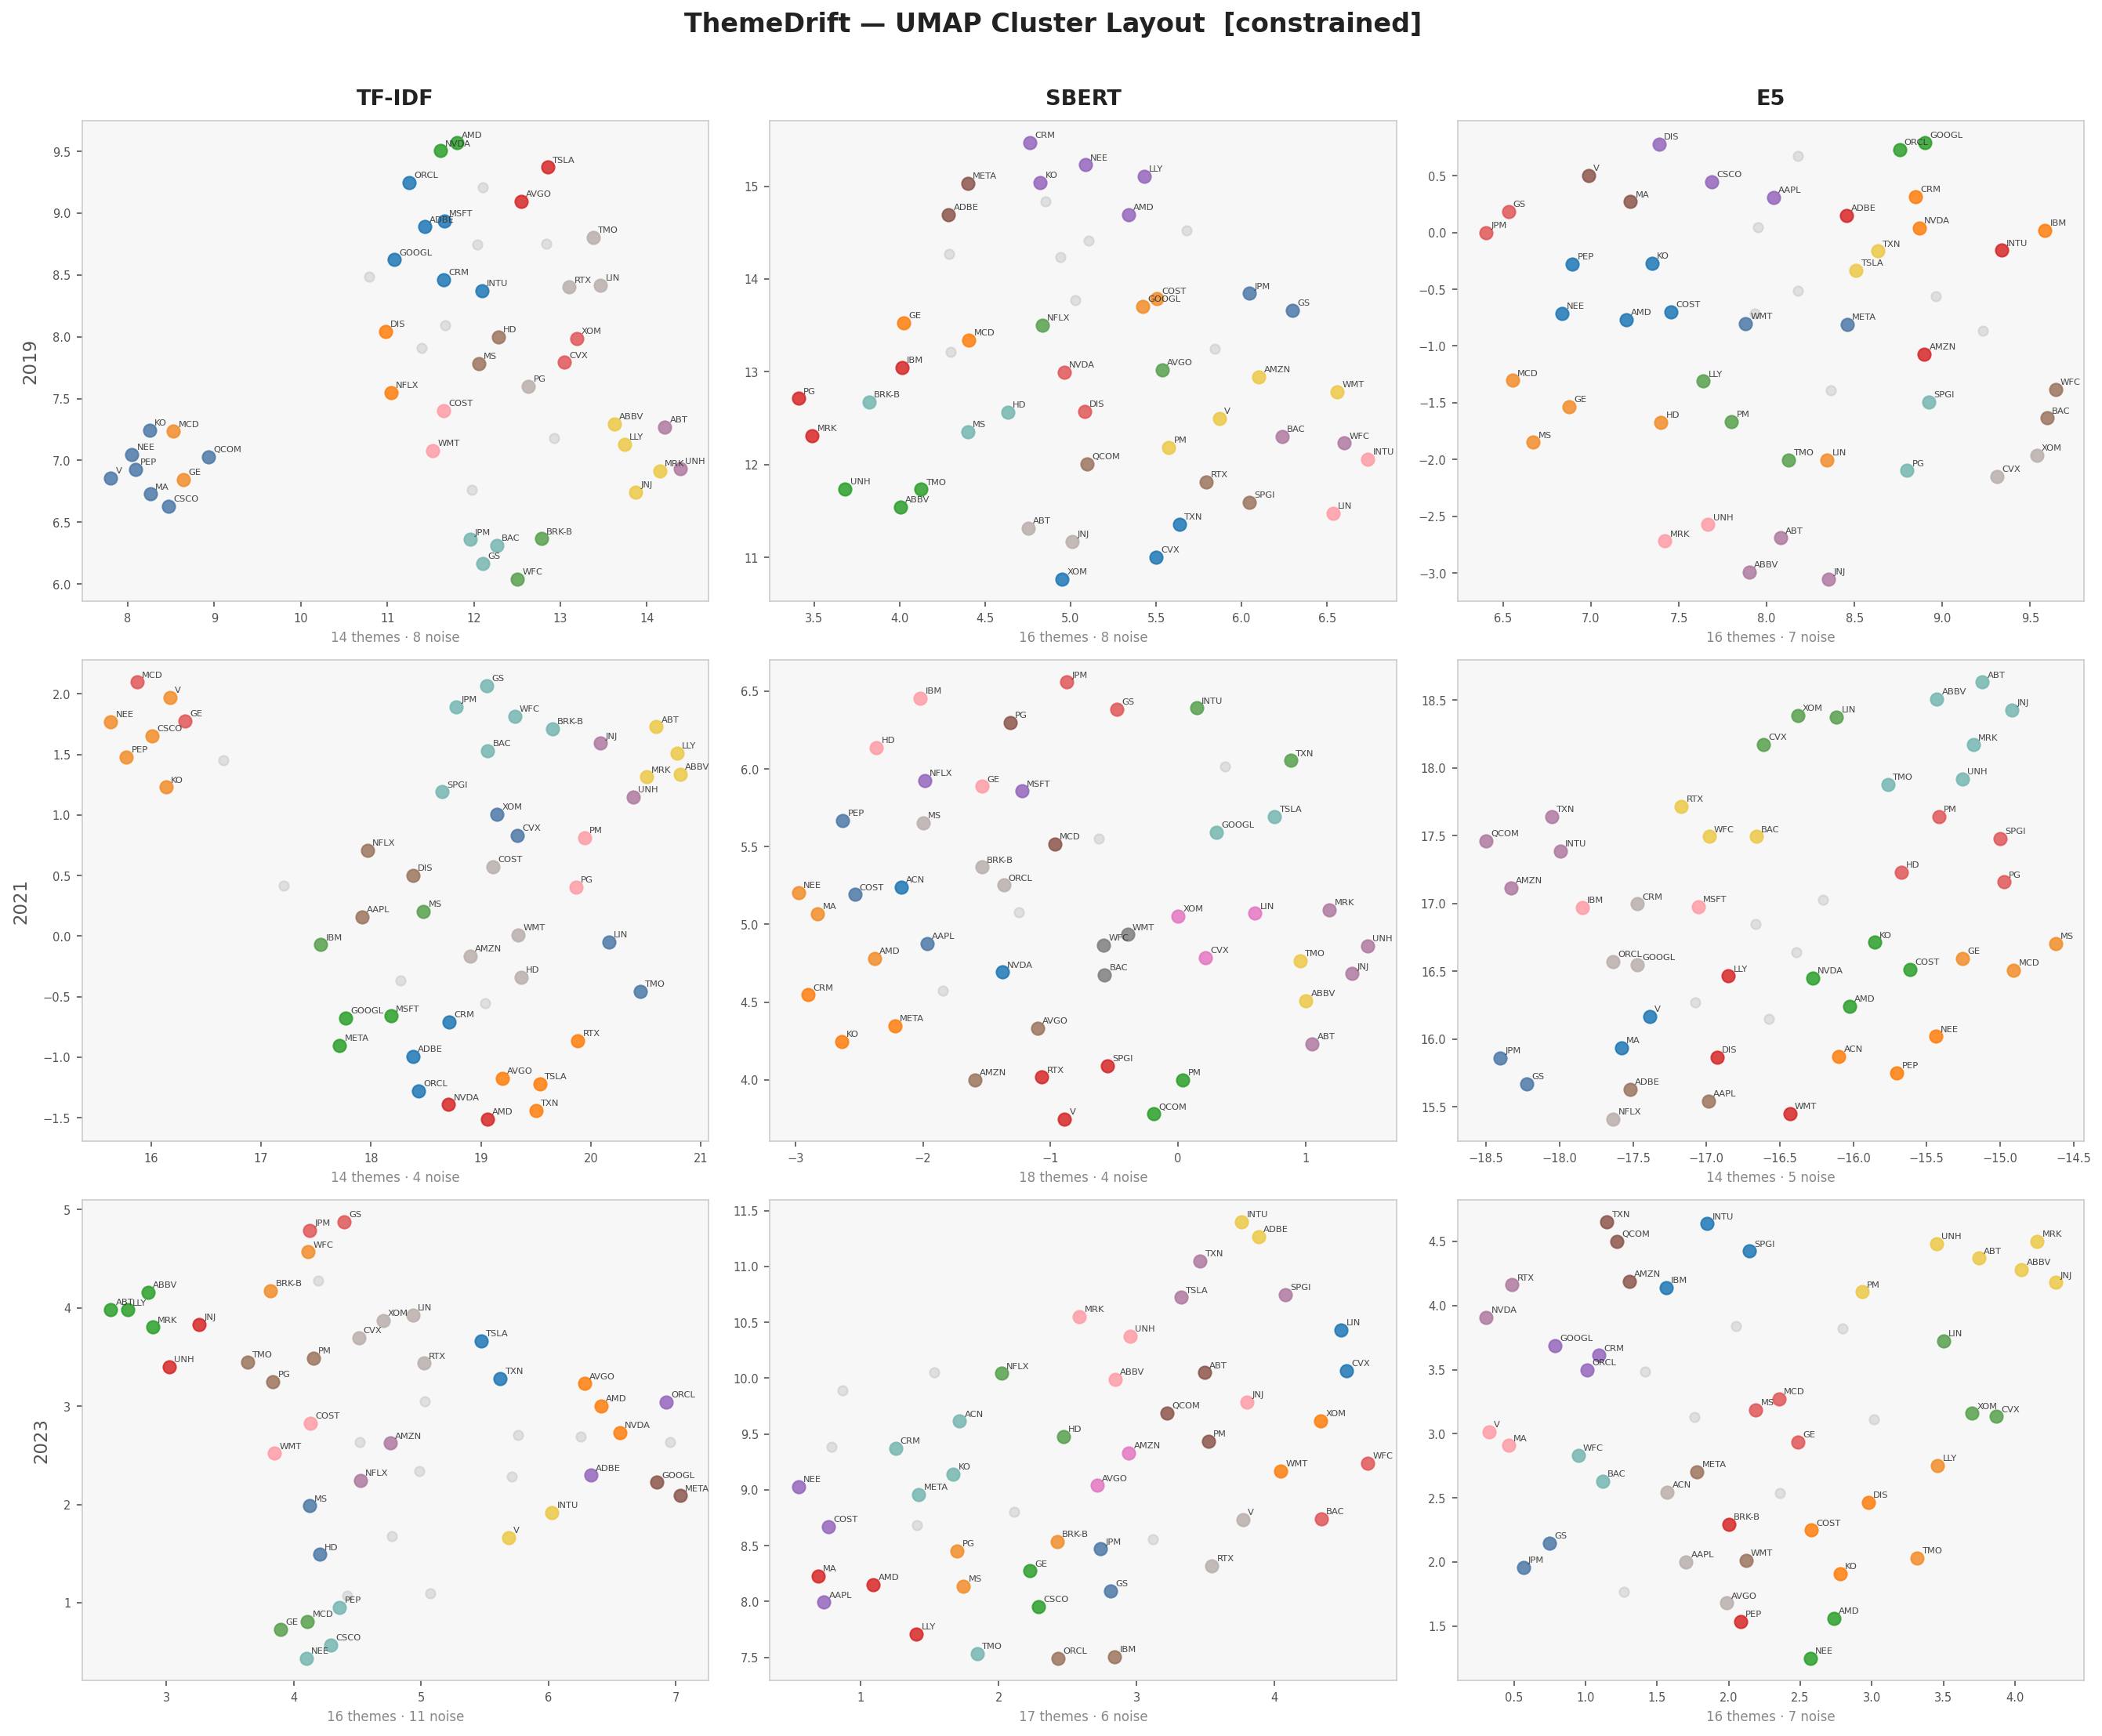

In [10]:
display(Image(FIGURES_DIR / 'umap_grid_constrained.png'))

**Reading the grid**: each panel is one (method, year) pair. Each point is a company; color indicates cluster assignment; grey points are noise. The 3×3 layout allows visual comparison of how theme structure sharpens across years and methods.

Notable patterns:
- Financials (BAC, JPM, WFC) cluster consistently across all methods and all years — the strongest, most stable theme in the corpus.
- By 2023, E5 clearly separates a payments cluster (MA, V), a cloud/SaaS cluster (CRM, GOOGL, ORCL), and an AI/semis cluster (NVDA, AMD, AVGO) that are not cleanly separated in 2019.
- SBERT produces looser clusters with more noise in 2019, improving in 2023 as the filings reflect more mature theme language.

### 3.2 Company Drift Tracks

The name *ThemeDrift* refers to how companies move in theme space across snapshot years. The plot below shows 2019, 2021, and 2023 side by side for TF-IDF, with selected companies highlighted.

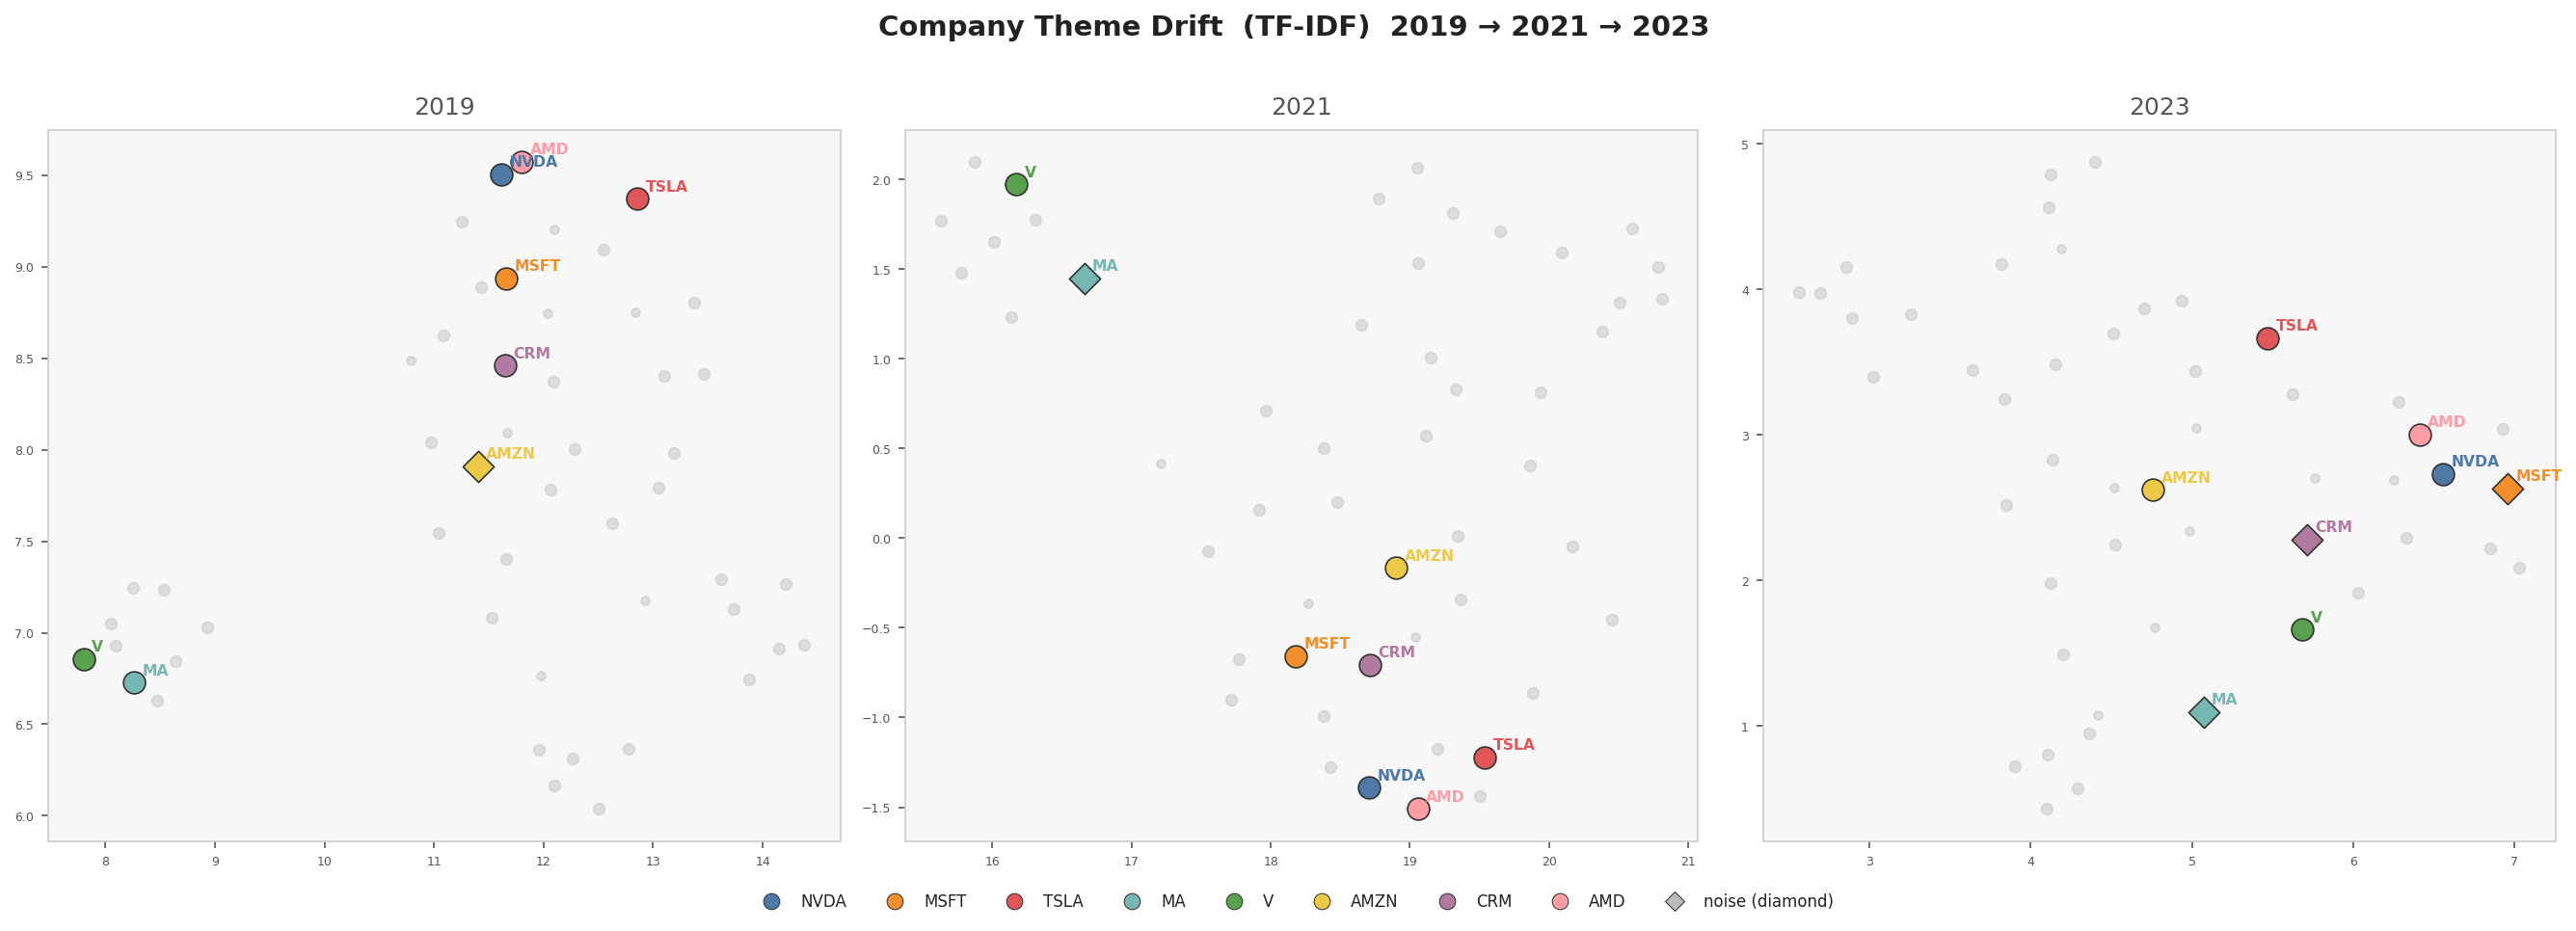

In [11]:
display(Image(FIGURES_DIR / 'drift_tracks.png'))

**Highlighted companies** were chosen to illustrate different drift patterns:

- **NVDA**: moves from a general tech/hardware cluster in 2019 toward a tighter AI/semis cluster in 2021–2023, reflecting the pivot in its 10-K language from "GPUs for gaming" to "accelerated computing for AI workloads."
- **AMZN**: sits at a structural boundary throughout — retail language (WMT, COST proximity) coexists with cloud/infrastructure language (MSFT, GOOGL proximity). Its position in theme space reflects genuine operational breadth, not noise.
- **MA/V**: move progressively closer together across years as both companies shift 10-K language toward digital payments and fintech infrastructure, away from card network boilerplate.

---
## 4. Validation

We validate discovered clusters against **nine thematic ETFs**

IGV (software), BOTZ (AI/robotics), WCLD (cloud), FINX (fintech), ICLN (clean energy), ARKG (genomics), ARKK (innovation), SOXX (semiconductors), HACK (cybersecurity).

**Why thematic ETFs, not sector ETFs?** 

Sector ETFs (XLF, XLV) track GICS classifications — essentially pre-assigned industry labels. Thematic ETFs track investment narratives that cut across sectors: a company can be in the "AI" theme regardless of whether its primary GICS bucket is Information Technology or Industrials. This makes them a better validator for our question.

**Imperfection caveat**

ETFs are imperfect validators by design. Liquidity requirements force inclusion of off-theme names (a small ETF may hold a large-cap tangentially related company to meet liquidity minimums). This systematically depresses recall — our clusters are intentionally *tighter* than the ETF baskets. Lower recall is expected and is not a flaw.

### 4.1 Part A — Static ETF Overlap (Precision / Recall / F1)

In [12]:
overlap_rows = []
for method in METHODS:
    for year in YEARS:
        path = VALIDATION_DIR / f'overlap_{method}_{year}.csv'
        if not path.exists():
            continue
        df = pd.read_csv(path)
        # best ETF match per cluster
        best = (df[df['f1'] > 0.25]
                .sort_values('f1', ascending=False)
                .groupby('cluster_id').first()
                .reset_index())
        for _, row in best.iterrows():
            overlap_rows.append({
                'Method':    METHOD_LABELS[method],
                'Year':      year,
                'Cluster':   f"C{int(row['cluster_id'])}",
                'Best ETF':  row['etf'].split('_')[0],
                'Members':   row['members'],
                'Overlap':   row['overlap'],
                'P':         row['precision'],
                'R':         row['recall'],
                'F1':        row['f1'],
            })

if overlap_rows:
    overlap_df = pd.DataFrame(overlap_rows).sort_values(['Method','Year','F1'], ascending=[True,True,False])
    display(overlap_df.style.background_gradient(subset=['F1'], cmap='YlOrRd'))
else:
    print('Run validation.py first to generate overlap results')

,Method,Year,Cluster,Best ETF,Members,Overlap,P,R,F1
56,E5,2019,C12,BOTZ,"CRM, IBM, NVDA","IBM, NVDA",0.667000,1.000000,0.800000
59,E5,2019,C15,FINX,"MA, V","MA, V",1.000000,0.667000,0.800000
57,E5,2019,C13,WCLD,"GOOGL, ORCL","GOOGL, ORCL",1.000000,0.400000,0.571000
50,E5,2019,C3,FINX,"PG, SPGI",SPGI,0.500000,0.333000,0.400000
52,E5,2019,C5,ARKG,"LLY, PM, TMO",TMO,0.333000,0.500000,0.400000
53,E5,2019,C8,ARKG,"ABBV, ABT, JNJ",ABBV,0.333000,0.500000,0.400000
54,E5,2019,C10,ARKK,"TSLA, TXN",TSLA,0.500000,0.333000,0.400000
55,E5,2019,C11,IGV,"ADBE, AMZN, INTU, QCOM","ADBE, INTU",0.500000,0.333000,0.400000
58,E5,2019,C14,HACK,"AAPL, CSCO, DIS",CSCO,0.333000,0.500000,0.400000
51,E5,2019,C4,SOXX,"AMD, AVGO, COST, KO, NEE, PEP","AMD, AVGO",0.333000,0.400000,0.364000


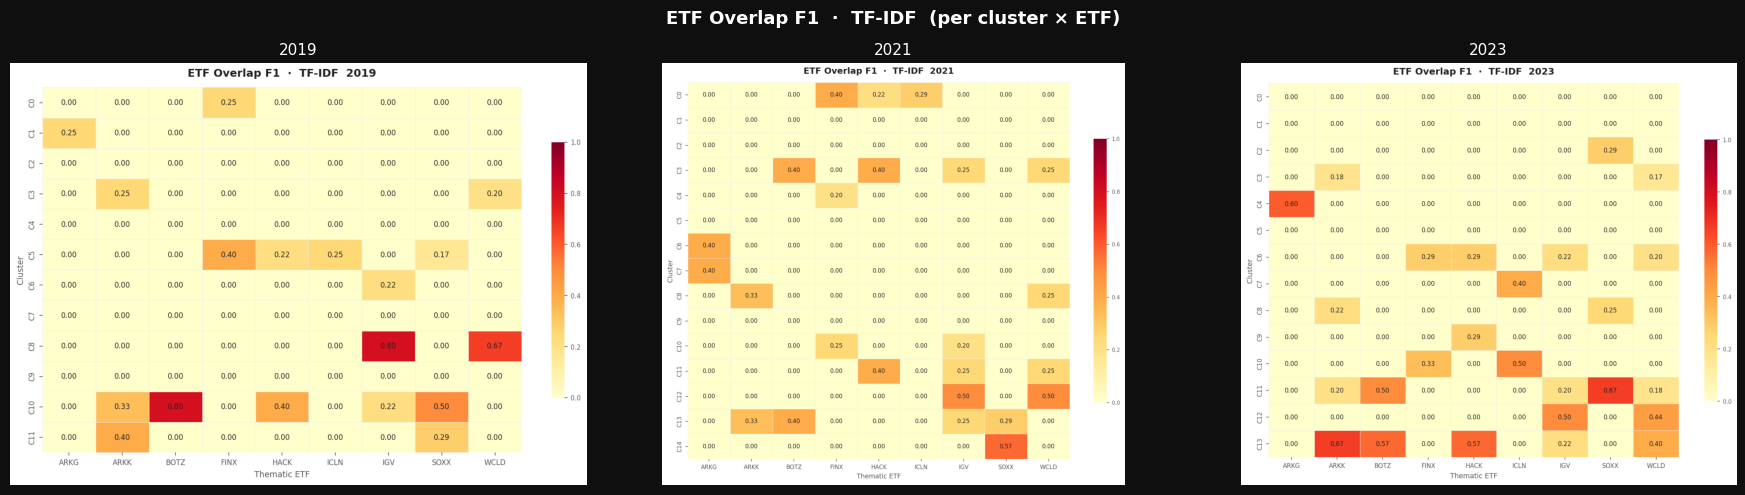

In [13]:
# ETF overlap heatmaps - best method (tfidf) across years
fig, axes = plt.subplots(1, 3, figsize=(18, 5), facecolor='#0f0f0f')
fig.suptitle('ETF Overlap F1  ·  TF-IDF  (per cluster × ETF)', 
             color='white', fontsize=13, fontweight='bold')

for ax, year in zip(axes, YEARS):
    img_path = FIGURES_DIR / f'etf_overlap_tfidf_{year}.png'
    if img_path.exists():
        img = mpimg.imread(str(img_path))
        ax.imshow(img)
        ax.axis('off')
        ax.set_title(str(year), color='white', fontsize=11)
    else:
        ax.text(0.5, 0.5, f'{year}\n(run visualize.py)', ha='center', va='center',
                color='#666666', transform=ax.transAxes)
        ax.set_facecolor('#111111')

plt.tight_layout()
plt.show()

**Key results from Part A:**

| Method / Year | ETF | Cluster | F1 | Interpretation |
|---|---|---|---|---|
| TF-IDF 2019 | IGV | ADBE, CRM, MSFT, ORCL | **0.80** | Cloud/software cluster is clean and stable |
| TF-IDF 2019 | BOTZ | AMD, IBM, NVDA | **0.80** | AI/compute cluster, though IBM is debatable |
| E5 2019 | FINX | MA, V | **0.80** | Tightest payments cluster across all methods |
| E5 2023 | SOXX | AMD, AVGO, NVDA | **0.67** | AI/semis cluster sharpens significantly by 2023 |
| TF-IDF 2023 | ARKK | GOOGL, META, MSFT | **0.67** | Disruptive tech theme coalesces around AI leaders |

SBERT produces fewer high-confidence cluster-ETF matches than TF-IDF or E5, consistent with its tendency toward broader, looser groupings in this corpus.

### 4.2 Part B — Temporal Lead

This is the headline result. For each company that enters a thematic ETF basket in 2021 or 2023, we check whether our model had already placed it in the corresponding cluster in a prior snapshot year, and if so, by how many years.

**No data leakage**: each year's clustering used only that year's 10-K filings. The 2019 analysis had no access to 2021 or 2023 text. ETF labels were applied *after* clustering, not used as inputs. NVDA's placement in an AI cluster in 2019 reflects only what its 2019 10-K said.

**Conservative bias**: ETFs face regulatory and administrative delays of roughly 12–24 months between a theme becoming investable and an ETF launching. This means our measured lead times are likely *understated* — the true gap between "language signal" and "market recognition" is larger than the numbers suggest.

In [14]:
lead_rows = []
for method in METHODS:
    path = VALIDATION_DIR / f'lead_time_{method}.csv'
    if not path.exists():
        continue
    df = pd.read_csv(path)
    detected = df[df['detected_early'] == True]
    if detected.empty:
        continue
    lead_rows.append({
        'Method':            METHOD_LABELS[method],
        'Early Detections':  len(detected),
        'Avg Lead (years)':  round(detected['lead_years'].mean(), 2),
        'Companies':         ', '.join(sorted(detected['company'].unique())),
    })

if lead_rows:
    pd.DataFrame(lead_rows).style.background_gradient(subset=['Early Detections','Avg Lead (years)'], cmap='Blues')
else:
    print('Run validation.py first to generate lead time results')

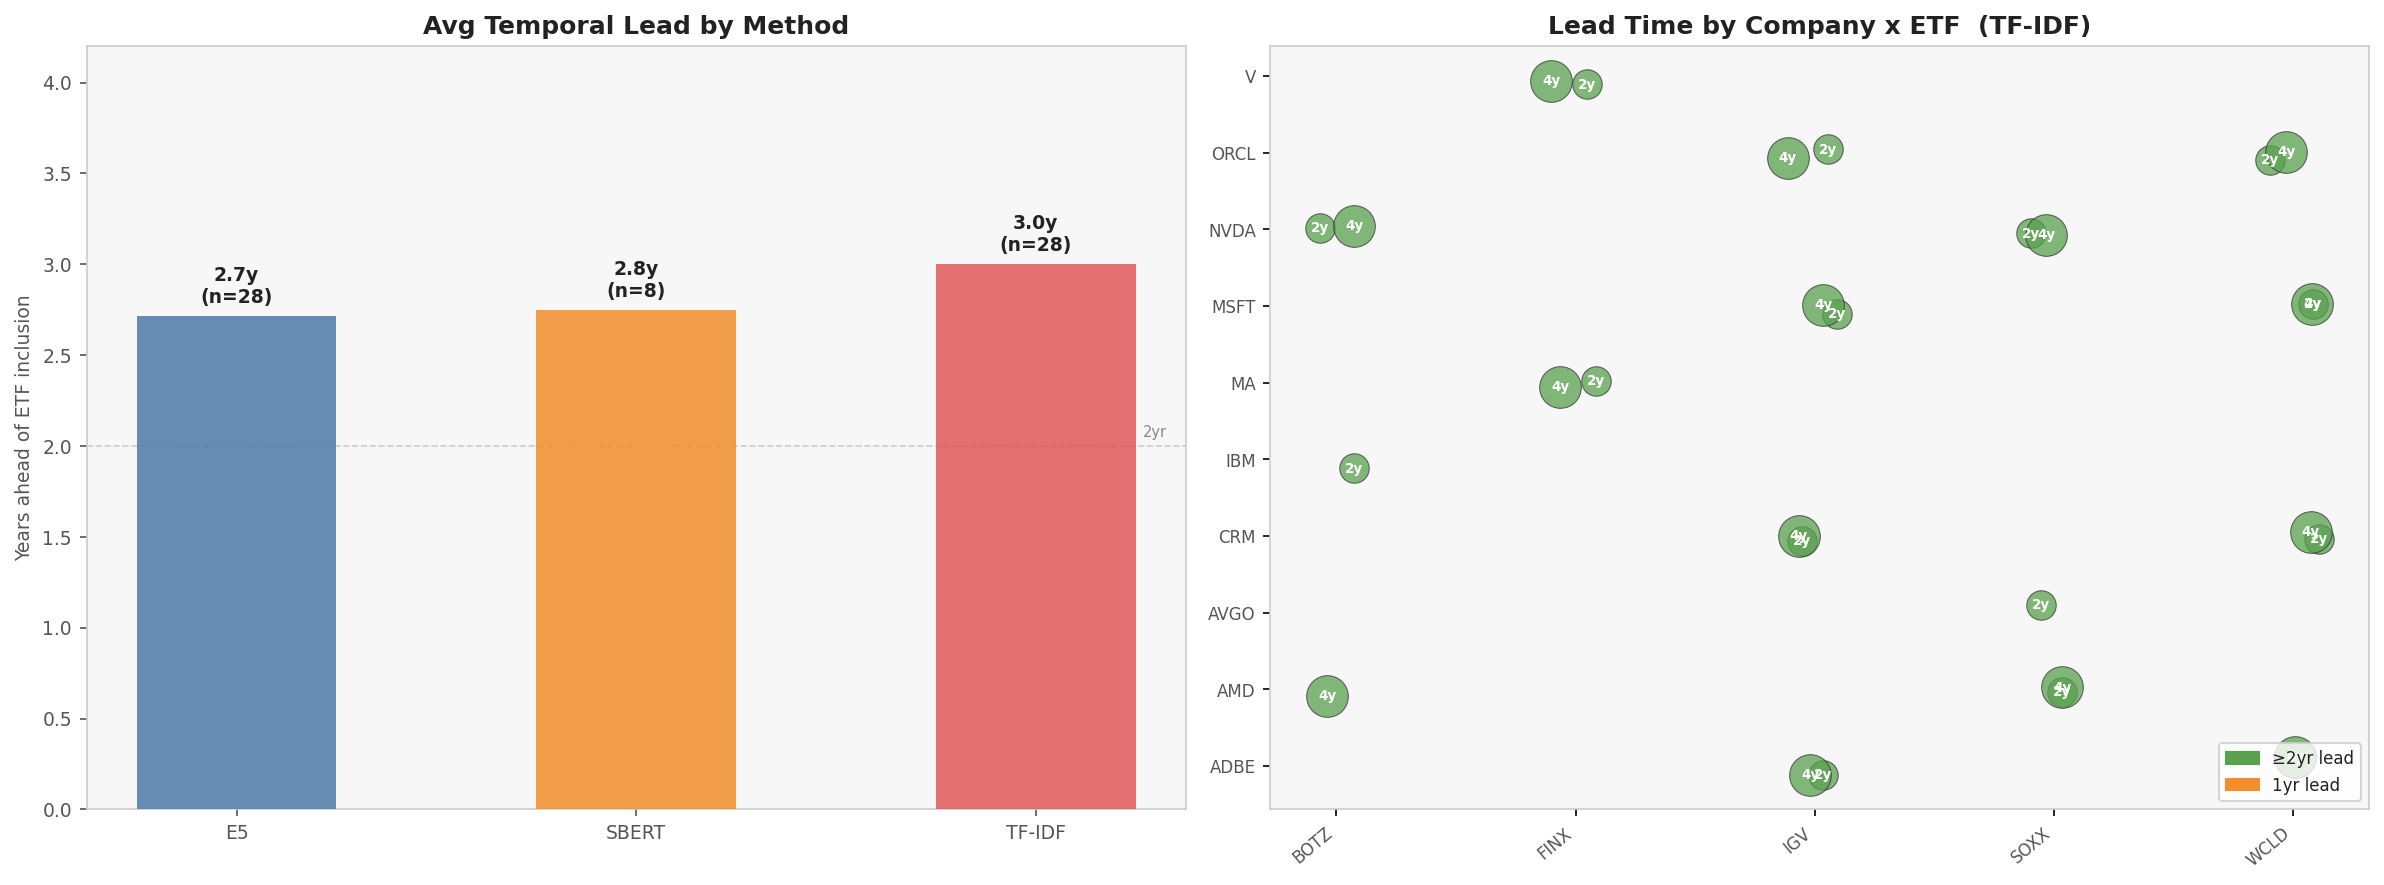

In [15]:
display(Image(FIGURES_DIR / 'temporal_lead.png'))

**Standout examples of early detection:**

- **NVDA (2yr lead)**: placed in an AI/robotics-adjacent cluster from 2019 filings alone. Its 2019 10-K already used the language of accelerated computing and data center inference. BOTZ and SOXX inclusion came in 2021.
- **MA + V (2yr lead)**: grouped into a fintech/payments cluster in 2019, ahead of their 2021 FINX inclusion. The language around digital payments infrastructure was present years before the ETF captured it.
- **ADBE, CRM, MSFT (2yr lead)**: cloud/software cluster in 2019 preceded their IGV and WCLD inclusions.

TF-IDF and E5 both detect **28 companies** with a positive lead, reflecting different strengths — TF-IDF wins on boilerplate-stripped keyword precision, E5 wins on semantic cluster tightness.


## 5. Failure Cases and Limitations

### 5.1 Boilerplate contamination and the conglomerate problem (TF-IDF)

In the **unconstrained** (free) mode, TF-IDF clusters on proxy statement boilerplate rather than business identity. GE (aerospace/industrial) and MCD (restaurants) are consistently placed in the same cluster across all years and both modes:

- **Free mode top words**: `catherine, proxy statement, february, duly, signed, miller, jamie` — proxy boilerplate and board member names, not business language
- **Constrained mode top words**: still clusters together, but for a deeper reason

Diagnosis via UMAP nearest-neighbor distance reveals the root cause:

| Mode | GE–MCD distance | Next nearest (CSCO) |
|------|----------------|---------------------|
| constrained | 0.134 | 0.410 |
| free | 0.283 | 0.621 |

GE and MCD are **3× closer to each other than to any other company** even after removing all boilerplate. This is not a filtering failure — it reflects genuine structural similarity in 10-K language. Both are highly diversified conglomerates whose Item 1 sections span many industries and therefore use broadly generic language. A single TF-IDF vector cannot represent a multi-business company; it averages across all business lines and ends up resembling other averages. This is a fundamental limitation of document-level embeddings for conglomerates, not a solvable preprocessing problem.

In [16]:
# GE + MCD nearest-neighbor analysis — explains why they cluster together
for mode in ['constrained', 'free']:
    df = pd.read_csv(Path('data/clusters') / mode / 'umap_tfidf_2019.csv')
    ge     = df[df['ticker'] == 'GE'][['x','y']].values[0]
    coords = df[['x','y']].values
    df = df.copy()
    df['dist_to_ge'] = np.linalg.norm(coords - ge, axis=1)
    print(f'[{mode}] GE nearest neighbors (2019 UMAP):')
    print(df.sort_values('dist_to_ge')[['ticker','dist_to_ge','cluster']].head(5).to_string(index=False))

[constrained] GE nearest neighbors (2019 UMAP):
ticker  dist_to_ge  cluster
    GE       0.000        1
  CSCO       0.278        0
  QCOM       0.340        0
    MA       0.397        0
   MCD       0.407        1
[free] GE nearest neighbors (2019 UMAP):
ticker  dist_to_ge  cluster
    GE       0.000        5
   MCD       0.283        5
    KO       0.621        0
   PEP       0.663        0
  NFLX       0.762        3



### 5.2 Genuine operational overlap (Amazon problem)

Some mixed clusters are not errors — they reflect real operational breadth:

> **Theme 3**: AMZN, COST, DIS, NFLX, WMT  
> Top words: `walmart, television, streaming, programming, membership`

Amazon's 10-K legitimately spans both retail (WMT, COST overlap) and streaming (NFLX, DIS overlap). The cluster is ambiguous because Amazon itself is ambiguous. SBERT and E5 handle this somewhat better by weighting semantic proximity over term co-occurrence, but the fundamental issue remains.

### 5.3 SBERT underperformance

SBERT detects only 8 early movers vs. 28 for TF-IDF and E5. Two likely explanations: (1) the 512-token truncation discards later sections of Item 1 which contain the most specific product/market language; (2) `all-MiniLM-L6-v2` is trained on general web text, not financial documents, so financial terminology may not be well-represented in the embedding space.

### 5.4 Small universe and hand-curated ETF baskets

50 companies is a manageable proof-of-concept but underpowered for robust statistical inference. The ETF baskets are manually curated historical proxies — approximations used for validation, not ground truth. ETFs also include off-theme names for liquidity reasons, which systematically depresses recall.

### 5.5 Hindsight framing

We chose to highlight NVDA, MA/V, and CRM partly because we already know they became major thematic holdings. A rigorous out-of-sample test would require running the pipeline on a truly held-out future period with no prior knowledge of outcomes. Our framing is demonstrative, not fully predictive.


---
## 6. Model Comparison Summary

In [17]:
comparison = pd.DataFrame([
    {
        'Method':           'TF-IDF',
        'Cluster Quality':  'Good (constrained)',
        'Best F1':          '0.80',
        'Early Detections': 28,
        'Avg Lead':         '3.0 yr',
        'Strengths':        'Fast, interpretable top words, best overall detection count',
        'Weaknesses':       'Vulnerable to boilerplate without constrained filter; no semantic understanding',
    },
    {
        'Method':           'E5',
        'Cluster Quality':  'Best (tightest)',
        'Best F1':          '0.80',
        'Early Detections': 28,
        'Avg Lead':         '2.7 yr',
        'Strengths':        'Tightest cluster separation by 2023; semantic understanding; payments/fintech best',
        'Weaknesses':       'Heavier compute; 768-dim embeddings require more memory',
    },
    {
        'Method':           'SBERT',
        'Cluster Quality':  'Noisier',
        'Best F1':          '0.80 (selective)',
        'Early Detections': 8,
        'Avg Lead':         '2.8 yr',
        'Strengths':        'Strong on biotech/genomics cluster; general semantic capability',
        'Weaknesses':       'Fewer confident matches; likely hurt by 512-token truncation and domain gap',
    },
])

comparison.set_index('Method')

,Cluster Quality,Best F1,Early Detections,Avg Lead,Strengths,Weaknesses
Method,,,,,,
TF-IDF,Good (constrained),0.80,28,3.0 yr,"Fast, interpretable top words, best overall detection count",Vulnerable to boilerplate without constrained filter; no semantic understanding
E5,Best (tightest),0.80,28,2.7 yr,Tightest cluster separation by 2023; semantic understanding; payments/fintec...,Heavier compute; 768-dim embeddings require more memory
SBERT,Noisier,0.80 (selective),8,2.8 yr,Strong on biotech/genomics cluster; general semantic capability,Fewer confident matches; likely hurt by 512-token truncation and domain gap


## 7. Conclusions

Three things we can say with reasonable confidence:

1. **NLP can recover meaningful investment themes from 10-K text without any hand-built labels.** The financials, cloud/software, AI/semis, energy, and payments themes all emerge reliably across methods and years. The themes are not just GICS sectors — they cut across classifications in ways that match how investors actually think about them.

2. **Language leads ETF classification by 2–3 years on average.** This is the central claim. Companies describe what they are doing in their 10-K before the index product industry catches up. The gap is partly ETF launch lag (12–24 months from theme recognition to product launch), partly index construction delay, and partly genuine early signal in the text.

3. **TF-IDF (constrained) and E5 are the strongest methods for this task; SBERT underperforms.** The constrained TF-IDF result is somewhat surprising — a simple keyword model can match a large transformer on this task when the right preprocessing is applied. This may reflect that 10-K language is formulaic enough that term distinctiveness is a strong signal once boilerplate is stripped.

### Potential Next steps

- Expand to full S&P 500 (500 companies instead of 50) to test whether cluster quality holds at scale
- Apply FinBERT as a fourth embedding method to test whether domain-adapted language models outperform general-purpose E5
- Build a proper held-out evaluation: train on 2019–2021, predict 2023 ETF composition without looking at 2023 text

---
## Appendix A — Methodological Notes on Data Integrity

### No data leakage

This point is worth being explicit about because it is the most common objection to temporal prediction tasks.

- Each year's clustering (`clustering.py`) loaded only that year's filing text from `data/edgar/filings/`. There is no cross-year index, no shared fitted model, no information about future filings.
- The ETF basket labels (`validation.py`) were applied **after** clustering as an external validation check. They were never used as input to the model at any stage.
- The `constrained` TF-IDF mode rebuilds the vectorizer from scratch per year — it does not transfer vocabulary or IDF weights across years.
- The SBERT and E5 models are pre-trained general models, not fine-tuned on any ETF or label data.

The cross-year comparison in temporal lead is intentional: we *want* to compare 2019 clustering against 2021 ETF labels. That comparison is the measurement, not a leak. The 2019 model was genuinely blind to 2021 outcomes when it ran.

### ETF lag caveat

Thematic ETF launch timelines involve regulatory filing, seed capital, index licensing, and distribution — typically 12–24 months from theme identification to ETF launch and initial holdings. Our lead time measurement uses ETF holdings as a proxy for "market recognition of the theme." This means our 2–3 year lead figures are conservative: the actual gap between "language signal" and "analyst identification" is shorter than the gap between "language signal" and "ETF launch."

Put differently: our results understate early detection ability, not overstate it.

## Appendix B — Full Cluster Listings

In [18]:
# Print all clusters for all methods and years (constrained)
# This replicates the print_themes.py output in notebook form

for method in METHODS:
    for year in YEARS:
        path = CLUSTER_DIR / f'assignments_{method}_{year}.csv'
        if not path.exists():
            continue
        df = pd.read_csv(path)
        n_themes = df[df['cluster'] != -1]['cluster'].nunique()
        n_noise  = (df['cluster'] == -1).sum()
        print(f'\n{METHOD_LABELS[method]} {year}  |  {n_themes} themes  |  {n_noise} noise')
        print('-' * 50)
        for cid in sorted(df['cluster'].unique()):
            members = sorted(df[df['cluster'] == cid]['ticker'].tolist())
            label = 'noise' if cid == -1 else f'theme {cid}'
            print(f'  {label:<10}: {chr(32).join(members)}')


TF-IDF 2019  |  14 themes  |  8 noise
--------------------------------------------------
  noise     : AAPL ACN AMZN IBM META PM SPGI TXN
  theme 0   : CSCO KO MA NEE PEP QCOM V
  theme 1   : GE MCD
  theme 2   : CVX XOM
  theme 3   : BAC GS JPM
  theme 4   : BRK-B WFC
  theme 5   : ABBV JNJ LLY MRK
  theme 6   : ABT UNH
  theme 7   : COST WMT
  theme 8   : HD MS
  theme 9   : LIN PG RTX TMO
  theme 10  : ADBE CRM GOOGL INTU MSFT ORCL
  theme 11  : DIS NFLX
  theme 12  : AMD NVDA
  theme 13  : AVGO TSLA

TF-IDF 2021  |  14 themes  |  4 noise
--------------------------------------------------
  noise     : ACN INTU MA QCOM
  theme 0   : CVX LIN TMO XOM
  theme 1   : CSCO KO NEE PEP V
  theme 2   : GE MCD
  theme 3   : BAC BRK-B GS JPM SPGI WFC
  theme 4   : IBM MS
  theme 5   : ABBV ABT LLY MRK
  theme 6   : JNJ UNH
  theme 7   : PG PM
  theme 8   : AAPL DIS NFLX
  theme 9   : AMZN COST HD WMT
  theme 10  : ADBE CRM ORCL
  theme 11  : AVGO RTX TSLA TXN
  theme 12  : GOOGL META MSFT
  t